# Inverse PINN for a 2D compressible Neo-Hookean solid

This notebook solves an inverse hyperelasticity problem on the reference square

$$
\Omega_0=[0,1]^2.
$$

The manufactured displacement is

$$
\mathbf u(X,Y)=
\begin{bmatrix}
0.1(X^2+Y^2)\\
0.05Y^2
\end{bmatrix}.
$$

Young's modulus and Poisson's ratio are unknown trainable material parameters. Their hidden values, used only to manufacture the fixed reference problem, are

$$
E_{\mathrm{true}}=1000,
\qquad
\nu_{\mathrm{true}}=0.3.
$$

A compressible Neo-Hookean plane-strain model is used:

$$
W(\mathbf F)
=\frac{\mu}{2}(I_1-2)-\mu\ln J
+\frac{\lambda}{2}(\ln J)^2,
$$

$$
\mathbf F=\mathbf I+\nabla_X\mathbf u,
\qquad
J=\det\mathbf F,
\qquad
I_1=\operatorname{tr}(\mathbf F^{\mathsf T}\mathbf F).
$$

During training, the Lam\'e parameters are computed from the identified values $E_\theta$ and $\nu_\theta$:

$$
\mu_\theta=\frac{E_\theta}{2(1+\nu_\theta)},
\qquad
\lambda_\theta=
\frac{E_\theta\nu_\theta}
{(1+\nu_\theta)(1-2\nu_\theta)}.
$$

The first Piola--Kirchhoff stress and equilibrium equation are

$$
\mathbf P_\theta
=\mu_\theta(\mathbf F_\theta-\mathbf F_\theta^{-\mathsf T})
+\lambda_\theta\ln J_\theta\,\mathbf F_\theta^{-\mathsf T},
\qquad
\operatorname{Div}_X\mathbf P_\theta+\mathbf B=\mathbf0.
$$

The body force is manufactured once from the exact displacement and the hidden true material parameters. Training points update the network and material parameters, validation points select the best complete checkpoint, and test points are used only for the final evaluation.

## 1. Imports


In [1]:
import copy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

OUTPUT_DIR = Path("imgs")
OUTPUT_DIR.mkdir(exist_ok=True)


/home/eliska/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2. Settings

The physical problem, five-hidden-layer displacement network, Adam/L-BFGS training, PDE loss weight, and validation rule are unchanged. Only the supervised data sets use fixed master pools: increasing a train, validation, or test data count keeps the earlier coordinates and noisy observations in that split.

`DATA_LOCATION_MODE = "whole_domain"` preserves the original random data locations. `"near_boundary"` draws random interior data only within `BOUNDARY_BAND * L` of an edge. PDE train, validation, and test points are freshly constructed uniform shifted Cartesian grids for the chosen `N_SIDE_PDE_*`. Boundary points use the original `torch.linspace` rule.


In [2]:
USE_DATA = True
DATA_MODE = "noisy"
NOISE_RELATIVE_STD = 0.02
assert DATA_MODE in {"exact", "noisy"}

L = 1.0
E_TRUE = 1.0
POISSON_TRUE = 0.3
MU_TRUE = E_TRUE / (2.0 * (1.0 + POISSON_TRUE))
LAME_LAMBDA_TRUE = (
    E_TRUE * POISSON_TRUE
    / ((1.0 + POISSON_TRUE) * (1.0 - 2.0 * POISSON_TRUE))
)

E_INITIAL = 2.0
POISSON_INITIAL = 0.01

N_SIDE_PDE_TRAIN = 70
N_SIDE_PDE_VALIDATION = 20
N_SIDE_PDE_TEST = 20
PDE_BATCH_SIZE = 64
N_BOUNDARY_PER_EDGE = 40

N_DATA_TRAIN = 50
N_DATA_VALIDATION = 20
N_DATA_TEST = 20
MAX_N_DATA_TRAIN = 1000
MAX_N_DATA_VALIDATION = 400
MAX_N_DATA_TEST = 400
DATA_LOCATION_MODE = "whole_domain"  # "whole_domain" or "near_boundary"
BOUNDARY_BAND = 0.03
assert DATA_LOCATION_MODE in {"whole_domain", "near_boundary"}
assert 0.0 < BOUNDARY_BAND < 0.5

EPOCHS = 2000
LBFGS_EPOCHS = 100
ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS
LR = 1e-3
SEED = 42
WEIGHT = 1e-0

assert 1 <= N_DATA_TRAIN <= MAX_N_DATA_TRAIN
assert 1 <= N_DATA_VALIDATION <= MAX_N_DATA_VALIDATION
assert 1 <= N_DATA_TEST <= MAX_N_DATA_TEST
torch.manual_seed(SEED)
print(f"True Young's modulus: {E_TRUE:.1f}")
print(f"True Poisson ratio: {POISSON_TRUE:.3f}")
print(f"True Lamé lambda: {LAME_LAMBDA_TRUE:.6f}")
print(f"True shear modulus mu: {MU_TRUE:.6f}")
print(f"Initial Young's modulus estimate: {E_INITIAL:.1f}")
print(f"Initial Poisson-ratio estimate: {POISSON_INITIAL:.3f}")
print(f"Displacement data mode: {DATA_MODE}")
if DATA_MODE == "noisy":
    print(f"Relative noise standard deviation: {NOISE_RELATIVE_STD:.1%}")


True Young's modulus: 1.0
True Poisson ratio: 0.300
True Lamé lambda: 0.576923
True shear modulus mu: 0.384615
Initial Young's modulus estimate: 2.0
Initial Poisson-ratio estimate: 0.010
Displacement data mode: noisy
Relative noise standard deviation: 2.0%


## 3. Exact solution, boundary conditions, and manufactured body force

The exact displacement is

$$
\mathbf u(X,Y)=
\begin{bmatrix}
0.1(X^2+Y^2)\\
0.05Y^2
\end{bmatrix}.
$$

The deformation gradient is

$$
\mathbf F(X,Y)=
\begin{bmatrix}
1+0.2X & 0.2Y\\
0 & 1+0.1Y
\end{bmatrix},
\qquad
J=(1+0.2X)(1+0.1Y)>0.
$$

Dirichlet conditions are prescribed on the complete boundary:

$$
\mathbf u(0,Y)=
\begin{bmatrix}0.1Y^2\\0.05Y^2\end{bmatrix},
\qquad
\mathbf u(1,Y)=
\begin{bmatrix}0.1(1+Y^2)\\0.05Y^2\end{bmatrix},
$$

$$
\mathbf u(X,0)=
\begin{bmatrix}0.1X^2\\0\end{bmatrix},
\qquad
\mathbf u(X,1)=
\begin{bmatrix}0.1(X^2+1)\\0.05\end{bmatrix}.
$$

The manufactured reference body force is

$$
\mathbf B=-\operatorname{Div}_X\mathbf P_{\mathrm{exact}},
$$

where $\mathbf P_{\mathrm{exact}}$ is evaluated with $E_{\mathrm{true}}$ and $\nu_{\mathrm{true}}$. The resulting body force is fixed during training and is never recomputed from $E_\theta$ or $\nu_\theta$.

In [3]:
def exact_displacement(xy):
    X = xy[:, 0:1]
    Y = xy[:, 1:2]
    ux = 0.1 * (X**2 + Y**2)
    uy = 0.05 * Y**2
    return torch.cat((ux, uy), dim=1)


def exact_deformation_gradient(xy):
    X = xy[:, 0:1]
    Y = xy[:, 1:2]
    row_1 = torch.cat((1.0 + 0.2 * X, 0.2 * Y), dim=1)
    row_2 = torch.cat((torch.zeros_like(X), 1.0 + 0.1 * Y), dim=1)
    return torch.stack((row_1, row_2), dim=1)


def first_piola_from_F(F, lame_lambda, shear_mu):
    J = torch.linalg.det(F)
    J_safe = torch.clamp(J, min=1e-8)
    inverse_transpose = torch.linalg.inv(F).transpose(1, 2)
    logarithmic_term = torch.log(J_safe).view(-1, 1, 1)
    P = (shear_mu * (F - inverse_transpose) + lame_lambda * logarithmic_term * inverse_transpose)
    return P, J


def exact_first_piola_stress(xy):
    P, _ = first_piola_from_F(exact_deformation_gradient(xy), LAME_LAMBDA_TRUE, MU_TRUE)
    return P


def body_force(xy):
    X = xy[:, 0:1]
    Y = xy[:, 1:2]
    a = 1.0 + 0.2 * X
    b = 0.2 * Y
    c = 1.0 + 0.1 * Y
    q = LAME_LAMBDA_TRUE * torch.log(a * c) - MU_TRUE

    divergence_x = (0.4 * MU_TRUE + 0.2 * (LAME_LAMBDA_TRUE - q) / a**2)
    divergence_y = (0.1 * MU_TRUE + 0.1 * (LAME_LAMBDA_TRUE - q) / c**2 - 0.2 * b * (LAME_LAMBDA_TRUE - q) / (c * a**2))
    return -torch.cat((divergence_x, divergence_y), dim=1)


def observed_displacement(xy, seed):
    exact = exact_displacement(xy)
    if DATA_MODE == "exact":
        return exact

    component_scales = torch.tensor([[0.2, 0.05]], dtype=exact.dtype)
    generator = torch.Generator().manual_seed(seed)
    noise = torch.randn(exact.shape, generator=generator, dtype=exact.dtype)
    return exact + NOISE_RELATIVE_STD * component_scales * noise

## 4. Neural network and trainable material parameters

The original neural network continues to approximate the two displacement components. Two additional scalar variables represent the unknown Young's modulus and Poisson's ratio.

Both quantities are registered directly as trainable PyTorch parameters,

$$
E_\theta=\texttt{nn.Parameter}(E_{\mathrm{initial}}),
\qquad
\nu_\theta=\texttt{nn.Parameter}(\nu_{\mathrm{initial}}).
$$

No exponential, sigmoid, clipping, or other parameterization is applied. The Lam\'e parameters are calculated directly from the current values of $E_\theta$ and $\nu_\theta$.

In [4]:
class InversePINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
                                            nn.Linear(2, 28),
                                            nn.Tanh(), 
                                            nn.Linear(28, 28), 
                                            nn.Tanh(), 
                                            nn.Linear(28, 28), 
                                            nn.Tanh(), 
                                            nn.Linear(28, 28), 
                                            nn.Tanh(), 
                                            nn.Linear(28, 28), 
                                            nn.Tanh(), 
                                            nn.Linear(28, 2))
        

        self.E = nn.Parameter(torch.tensor(E_INITIAL))
        self.nu = nn.Parameter(torch.tensor(POISSON_INITIAL))

    def forward(self, xy):
        return self.net(xy)

    def young_modulus(self):
        return self.E

    def poisson_ratio(self):
        return self.nu

    def material_parameters(self):
        E = self.young_modulus()
        nu = self.poisson_ratio()
        shear_mu = E / (2.0 * (1.0 + nu))
        lame_lambda = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
        return E, nu, lame_lambda, shear_mu


model = InversePINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)
initial_E, initial_nu, initial_lambda, initial_mu = model.material_parameters()
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Initial E: {initial_E.item():.6f}")
print(f"Initial nu: {initial_nu.item():.6f}")
print(f"Initial Lamé lambda: {initial_lambda.item():.6f}")
print(f"Initial shear modulus mu: {initial_mu.item():.6f}")

Trainable parameters: 3,392
Initial E: 2.000000
Initial nu: 0.010000
Initial Lamé lambda: 0.020206
Initial shear modulus mu: 0.990099


## 5. Uniform PDE train, validation, and test grids

For each selected `N_SIDE_PDE_*`, all PDE points form one shifted uniform Cartesian grid with `N_SIDE_PDE_* ** 2` coordinates. Changing the side length rebuilds that grid; PDE grids are not nested. Different offsets prevent overlap among the train, validation, and test sets. During Adam, only the PDE training grid is mini-batched.


In [5]:
def shifted_uniform_grid_2d(n_side, shift_x, shift_y):
    indices = torch.arange(n_side, dtype=torch.get_default_dtype())
    x = L * (indices + shift_x) / n_side
    y = L * (indices + shift_y) / n_side
    X, Y = torch.meshgrid(x, y, indexing="xy")
    return torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)


def grids_overlap(first, second):
    differences = torch.abs(first[:, None, :] - second[None, :, :])
    identical = torch.all(differences < 1e-12, dim=2)
    return bool(torch.any(identical))


x_pde_train = shifted_uniform_grid_2d(N_SIDE_PDE_TRAIN, shift_x=0.50, shift_y=0.50)
x_pde_validation = shifted_uniform_grid_2d(N_SIDE_PDE_VALIDATION, shift_x=0.37, shift_y=0.61)
x_pde_test = shifted_uniform_grid_2d(N_SIDE_PDE_TEST, shift_x=0.73, shift_y=0.29)

assert not grids_overlap(x_pde_train, x_pde_validation)
assert not grids_overlap(x_pde_train, x_pde_test)
assert not grids_overlap(x_pde_validation, x_pde_test)

print(
    f"PDE points: {len(x_pde_train)} train, "
    f"{len(x_pde_validation)} validation, {len(x_pde_test)} test"
)
print("PDE grids overlap: False")
print(f"Adam PDE batch size: {PDE_BATCH_SIZE}")

pde_batch_generator = torch.Generator().manual_seed(SEED + 1)
pde_train_loader = DataLoader(TensorDataset(x_pde_train), batch_size=PDE_BATCH_SIZE, shuffle=True, generator=pde_batch_generator,)


PDE points: 4900 train, 400 validation, 400 test
PDE grids overlap: False
Adam PDE batch size: 64


## 6. Boundary points and nested displacement observations

The exact nonhomogeneous Dirichlet boundary conditions on all four edges use the original evenly spaced `torch.linspace` coordinates. Training, validation, and test displacement observations are sampled from three independent fixed master pools. The selected data points and their exact/noisy targets are prefixes of those pools. Thus, changing one `N_DATA_*` count never moves earlier data points or regenerates their noise. In `"near_boundary"` mode, random observations are interior points inside a boundary strip of width `BOUNDARY_BAND * L`. Boundary points and all training observations remain full batch at every optimizer step.


In [6]:
edge_coordinate = torch.linspace(0.0, L, N_BOUNDARY_PER_EDGE).view(-1, 1)
zeros, ones = torch.zeros_like(edge_coordinate), torch.ones_like(edge_coordinate)
xy_boundary = torch.cat((
    torch.cat((zeros, edge_coordinate), dim=1), torch.cat((ones, edge_coordinate), dim=1),
    torch.cat((edge_coordinate, zeros), dim=1), torch.cat((edge_coordinate, ones), dim=1),), dim=0)
u_boundary = exact_displacement(xy_boundary)


def sample_data_pool(capacity, seed):
    generator = torch.Generator().manual_seed(seed)
    if DATA_LOCATION_MODE == "whole_domain":
        return L * torch.rand(capacity, 2, generator=generator)
    accepted, total = [], 0
    while total < capacity:
        candidates = L * torch.rand(max(4 * capacity, 256), 2, generator=generator)
        distance = torch.minimum(candidates, L - candidates).min(dim=1).values
        selected = candidates[(distance > 0.0) & (distance < BOUNDARY_BAND * L)]
        accepted.append(selected)
        total += len(selected)
    return torch.cat(accepted, dim=0)[:capacity]


xy_data_train_pool = sample_data_pool(MAX_N_DATA_TRAIN, SEED + 10)
xy_data_validation_pool = sample_data_pool(MAX_N_DATA_VALIDATION, SEED + 11)
xy_data_test_pool = sample_data_pool(MAX_N_DATA_TEST, SEED + 12)
u_data_train_pool = observed_displacement(xy_data_train_pool, seed=SEED + 20)
u_data_validation_pool = observed_displacement(xy_data_validation_pool, seed=SEED + 21)
u_data_test_pool = observed_displacement(xy_data_test_pool, seed=SEED + 22)

xy_data_train, u_data_train = xy_data_train_pool[:N_DATA_TRAIN], u_data_train_pool[:N_DATA_TRAIN]
xy_data_validation, u_data_validation = xy_data_validation_pool[:N_DATA_VALIDATION], u_data_validation_pool[:N_DATA_VALIDATION]
xy_data_test, u_data_test = xy_data_test_pool[:N_DATA_TEST], u_data_test_pool[:N_DATA_TEST]
assert not grids_overlap(xy_data_train, xy_data_validation)
assert not grids_overlap(xy_data_train, xy_data_test)
assert not grids_overlap(xy_data_validation, xy_data_test)

print(f"Displacement data: {N_DATA_TRAIN} train, {N_DATA_VALIDATION} validation, {N_DATA_TEST} test")
print(f"Displacement data mode: {DATA_MODE}; locations: {DATA_LOCATION_MODE}")
print(f"Dirichlet boundary points: {len(xy_boundary)}")


Displacement data: 50 train, 20 validation, 20 test
Displacement data mode: noisy; locations: whole_domain
Dirichlet boundary points: 160


## 7. Physics residual and inverse training

The network approximates

$$
\mathbf u_\theta(X,Y)=
\begin{bmatrix}u_{x,\theta}\\u_{y,\theta}\end{bmatrix}.
$$

Automatic differentiation gives

$$
\mathbf F_\theta=\mathbf I+\nabla_X\mathbf u_\theta,
\qquad
J_\theta=\det\mathbf F_\theta,
$$

and the trainable material parameters give

$$
\mu_\theta=\frac{E_\theta}{2(1+\nu_\theta)},
\qquad
\lambda_\theta=
\frac{E_\theta\nu_\theta}
{(1+\nu_\theta)(1-2\nu_\theta)}.
$$

The predicted first Piola--Kirchhoff stress and equilibrium residual are

$$
\mathbf P_\theta
=\mu_\theta(\mathbf F_\theta-\mathbf F_\theta^{-\mathsf T})
+\lambda_\theta\ln J_\theta\,\mathbf F_\theta^{-\mathsf T},
$$

$$
\mathbf r_\theta
=\operatorname{Div}_X\mathbf P_\theta+\mathbf B_{\mathrm{true}}.
$$

The body force remains fixed at the value manufactured with the hidden true parameters. The training loss retains the original structure and PDE weight:

$$
\mathcal L_{\mathrm{train}}
=10^{-6}\mathcal L_{\mathrm{PDE}}
+\mathcal L_{\mathrm{BC}}
+\mathcal L_{\mathrm{data}}.
$$

During Adam training, only the PDE points are mini-batched. Boundary points and all supervised data are used in every optimizer step. Validation, testing, and L-BFGS use fixed full batches. The selected checkpoint contains the displacement-network parameters together with $E_\theta$ and $\nu_\theta$.

In [7]:
loss_history = []
pde_loss_history = []
bc_loss_history = []
data_loss_history = []
validation_loss_history = []
validation_pde_loss_history = []
validation_data_loss_history = []
E_history = []
poisson_history = []
lambda_history = []
mu_history = []

best_validation_loss = float("inf")
best_validation_pde_loss = None
best_validation_data_loss = None
best_epoch = None
best_model_state = None


def deformation_gradient_from_displacement(u, xy):
    ux = u[:, 0:1]
    uy = u[:, 1:2]
    grad_ux = torch.autograd.grad(ux, xy, torch.ones_like(ux), create_graph=True, retain_graph=True)[0]
    grad_uy = torch.autograd.grad(uy, xy, torch.ones_like(uy), create_graph=True, retain_graph=True)[0]
    row_1 = torch.cat((1.0 + grad_ux[:, 0:1], grad_ux[:, 1:2]), dim=1)
    row_2 = torch.cat((grad_uy[:, 0:1], 1.0 + grad_uy[:, 1:2]), dim=1)
    return torch.stack((row_1, row_2), dim=1)


def displacement_stress_and_residual(xy, create_graph):
    xy_local = xy.detach().clone().requires_grad_(True)
    u = model(xy_local)
    F = deformation_gradient_from_displacement(u, xy_local)
    _, _, lame_lambda, shear_mu = model.material_parameters()
    P, J = first_piola_from_F(F, lame_lambda, shear_mu)

    grad_P11 = torch.autograd.grad(P[:, 0, 0:1], xy_local, torch.ones_like(P[:, 0, 0:1]), create_graph=create_graph, retain_graph=True)[0]
    grad_P12 = torch.autograd.grad(P[:, 0, 1:2], xy_local, torch.ones_like(P[:, 0, 1:2]), create_graph=create_graph, retain_graph=True)[0]
    grad_P21 = torch.autograd.grad(P[:, 1, 0:1], xy_local, torch.ones_like(P[:, 1, 0:1]), create_graph=create_graph, retain_graph=True)[0]
    grad_P22 = torch.autograd.grad(P[:, 1, 1:2], xy_local, torch.ones_like(P[:, 1, 1:2]), create_graph=create_graph, retain_graph=True,)[0]

    divergence_x = grad_P11[:, 0:1] + grad_P12[:, 1:2]
    divergence_y = grad_P21[:, 0:1] + grad_P22[:, 1:2]
    divergence = torch.cat((divergence_x, divergence_y), dim=1)
    residual = divergence + body_force(xy_local)
    return u, P, residual, J


def compute_training_losses(xy_pde):
    _, _, residual, _ = displacement_stress_and_residual(xy_pde, create_graph=True)
    loss_pde = torch.mean(residual**2)

    boundary_error = model(xy_boundary) - u_boundary
    loss_bc = torch.mean(boundary_error**2)

    loss_data = torch.mean((model(xy_data_train) - u_data_train)**2)
    loss = WEIGHT * loss_pde + loss_bc + loss_data
    return loss, loss_pde, loss_bc, loss_data


def compute_validation_losses():
    _, _, residual, _ = displacement_stress_and_residual(x_pde_validation, create_graph=False)
    loss_pde = torch.mean(residual.detach()**2)

    with torch.no_grad():
        loss_data = torch.mean((model(xy_data_validation) - u_data_validation)**2)
    return WEIGHT * loss_pde + loss_data, loss_pde, loss_data


def update_checkpoint(epoch):
    global best_validation_loss, best_validation_pde_loss
    global best_validation_data_loss, best_epoch, best_model_state
    if epoch < 1000:
      for history in (validation_loss_history, validation_pde_loss_history, validation_data_loss_history):
        history.append(float("nan"))
      E, nu, lam, mu = model.material_parameters()
      E_history.append(E.detach().item()); poisson_history.append(nu.detach().item())
      lambda_history.append(lam.detach().item()); mu_history.append(mu.detach().item())
      return float("nan")
    model.eval()
    loss, loss_pde, loss_data = compute_validation_losses()
    values = loss.item(), loss_pde.item(), loss_data.item()
    validation_loss_history.append(values[0])
    validation_pde_loss_history.append(values[1])
    validation_data_loss_history.append(values[2])

    E, nu, lame_lambda, shear_mu = model.material_parameters()
    E_history.append(E.detach().item())
    poisson_history.append(nu.detach().item())
    lambda_history.append(lame_lambda.detach().item())
    mu_history.append(shear_mu.detach().item())

    if best_model_state is None or values[0] < best_validation_loss:
        best_validation_loss = values[0]
        best_validation_pde_loss = values[1]
        best_validation_data_loss = values[2]
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())

    model.train()
    return values[0]


for epoch in range(ADAM_EPOCHS):
    epoch_sums = np.zeros(4)
    samples = 0

    for (xy_pde_batch,) in pde_train_loader:
        optimizer_adam.zero_grad(set_to_none=True)
        losses = compute_training_losses(xy_pde_batch)
        losses[0].backward()
        optimizer_adam.step()

        batch_size = len(xy_pde_batch)
        epoch_sums += np.array([value.detach().item() for value in losses]) * batch_size
        samples += batch_size

    epoch_values = epoch_sums / samples
    loss_history.append(epoch_values[0])
    pde_loss_history.append(epoch_values[1])
    bc_loss_history.append(epoch_values[2])
    data_loss_history.append(epoch_values[3])
    validation_value = update_checkpoint(epoch)

    if epoch % 100 == 0:
        E_current, nu_current, _, _ = model.material_parameters()
        print(
            f"Adam | epoch {epoch:5d} | loss={epoch_values[0]:.3e} "
            f"| PDE={epoch_values[1]:.3e} | BC={epoch_values[2]:.3e} "
            f"| data={epoch_values[3]:.3e} "
            f"| E={E_current.item():.6f} "
            f"| nu={nu_current.item():.6f} "
            f"| validation={validation_value:.3e}"
        )


optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, history_size=50, line_search_fn="strong_wolfe")

for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch

    def closure():
        optimizer_lbfgs.zero_grad(set_to_none=True)
        loss, _, _, _ = compute_training_losses(x_pde_train)
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)
    loss, loss_pde, loss_bc, loss_data = compute_training_losses(x_pde_train)
    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    bc_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())
    validation_value = update_checkpoint(epoch)

    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        E_current, nu_current, _, _ = model.material_parameters()
        print(
            f"L-BFGS | epoch {epoch:5d} | loss={loss.item():.3e} "
            f"| E={E_current.item():.6f} "
            f"| nu={nu_current.item():.6f} "
            f"| validation={validation_value:.3e}"
        )


last_model_state = copy.deepcopy(model.state_dict())
model.load_state_dict(best_model_state)
model.eval()

best_E, best_nu, best_lambda, best_mu = model.material_parameters()
print(f"Best epoch: {best_epoch}")
print(f"Best combined validation loss: {best_validation_loss:.6e}")
print(f"Validation PDE loss: {best_validation_pde_loss:.6e}")
print(f"Validation data MSE: {best_validation_data_loss:.6e}")
print(f"Identified Young's modulus: {best_E.item():.8f}")
print(f"Identified Poisson ratio: {best_nu.item():.8f}")
print(f"Identified Lamé lambda: {best_lambda.item():.8f}")
print(f"Identified shear modulus mu: {best_mu.item():.8f}")

Adam | epoch     0 | loss=1.931e-02 | PDE=1.439e-02 | BC=2.920e-03 | data=1.996e-03 | E=1.991968 | nu=0.026771 | validation=nan
Adam | epoch   100 | loss=7.179e-06 | PDE=7.688e-07 | BC=7.050e-07 | data=5.705e-06 | E=1.168428 | nu=0.135785 | validation=nan
Adam | epoch   200 | loss=6.496e-06 | PDE=5.028e-07 | BC=4.192e-07 | data=5.574e-06 | E=1.095634 | nu=0.199763 | validation=nan
Adam | epoch   300 | loss=6.071e-06 | PDE=2.914e-07 | BC=3.076e-07 | data=5.473e-06 | E=1.074055 | nu=0.226015 | validation=nan
Adam | epoch   400 | loss=7.040e-06 | PDE=2.472e-07 | BC=8.056e-07 | data=5.987e-06 | E=1.053524 | nu=0.247519 | validation=nan
Adam | epoch   500 | loss=6.639e-06 | PDE=2.714e-07 | BC=5.970e-07 | data=5.770e-06 | E=1.041083 | nu=0.258732 | validation=nan
Adam | epoch   600 | loss=5.864e-06 | PDE=2.922e-07 | BC=1.941e-07 | data=5.378e-06 | E=1.033100 | nu=0.265783 | validation=nan
Adam | epoch   700 | loss=6.390e-06 | PDE=2.126e-07 | BC=4.930e-07 | data=5.685e-06 | E=1.026548 | nu=0.

## 8. Final test metrics

The independent PDE test grid and displacement test observations are used only after the best checkpoint has been restored. In addition to the original field and residual metrics, the report includes the identified values of $E$, $\nu$, $\lambda$, and $\mu$ and the relative errors in the two independently trained parameters.

In [8]:
model.eval()
u_test, P_test, residual_test, J_test = displacement_stress_and_residual(x_pde_test, create_graph=False)
u_test = u_test.detach()
P_test = P_test.detach()
residual_test = residual_test.detach()
J_test = J_test.detach()
u_exact_test = exact_displacement(x_pde_test)
P_exact_test = exact_first_piola_stress(x_pde_test)


def relative_l2(prediction, exact):
    return (torch.linalg.vector_norm(prediction - exact) / torch.linalg.vector_norm(exact)).item()


def r2_score(prediction, exact):
    ss_res = torch.sum((prediction - exact)**2)
    ss_tot = torch.sum((exact - torch.mean(exact))**2)
    return (1.0 - ss_res / ss_tot).item()


with torch.no_grad():
    boundary_mse = torch.mean((model(xy_boundary) - u_boundary)**2).item()
    data_test_mse = torch.mean((model(xy_data_test) - u_data_test)**2).item()

identified_E, identified_nu, identified_lambda, identified_mu = (model.material_parameters())
identified_E = identified_E.detach().item()
identified_nu = identified_nu.detach().item()
identified_lambda = identified_lambda.detach().item()
identified_mu = identified_mu.detach().item()

relative_E_error = abs(identified_E - E_TRUE) / abs(E_TRUE)
relative_nu_error = (abs(identified_nu - POISSON_TRUE) / abs(POISSON_TRUE))

metrics = {"data_mode": DATA_MODE,
    "best_epoch": best_epoch,
    "best_validation_loss": best_validation_loss,
    "identified_E": identified_E,
    "relative_E_error": relative_E_error,
    "identified_nu": identified_nu,
    "relative_nu_error": relative_nu_error,
    "identified_lambda": identified_lambda,
    "identified_mu": identified_mu,
    "displacement_R2_test": r2_score(u_test, u_exact_test),
    "displacement_relative_L2_test": relative_l2(u_test, u_exact_test),
    "first_piola_R2_test": r2_score(P_test, P_exact_test),
    "first_piola_relative_L2_test": relative_l2(P_test, P_exact_test)}

print("=" * 68)
print("INVERSE 2D NEO-HOOKEAN PINN TEST RESULTS")
print("=" * 68)
print(f"Data mode:                       {metrics['data_mode']}")
print(f"True Young's modulus:            {E_TRUE:.8f}")
print(f"Identified Young's modulus:      {metrics['identified_E']:.8f}")
print(f"Relative error in E:             {metrics['relative_E_error']:.6e}")
print(f"True Poisson ratio:              {POISSON_TRUE:.8f}")
print(f"Identified Poisson ratio:        {metrics['identified_nu']:.8f}")
print(f"Relative error in nu:            {metrics['relative_nu_error']:.6e}")
print(f"Displacement R2:                 {metrics['displacement_R2_test']:.8f}")
print(f"Displacement relative L2:        {metrics['displacement_relative_L2_test']:.6e}")
print(f"First Piola stress R2:           {metrics['first_piola_R2_test']:.8f}")
print(f"First Piola stress relative L2:  {metrics['first_piola_relative_L2_test']:.6e}")

print("=" * 68)

metrics

INVERSE 2D NEO-HOOKEAN PINN TEST RESULTS
Data mode:                       noisy
True Young's modulus:            1.00000000
Identified Young's modulus:      0.99642628
Relative error in E:             3.573716e-03
True Poisson ratio:              0.30000000
Identified Poisson ratio:        0.29170054
Relative error in nu:            2.766486e-02
Displacement R2:                 0.99993044
Displacement relative L2:        5.825088e-03
First Piola stress R2:           0.99754173
First Piola stress relative L2:  3.140379e-02


{'data_mode': 'noisy',
 'best_epoch': 1519,
 'best_validation_loss': 1.1606935913732741e-05,
 'identified_E': 0.9964262843132019,
 'relative_E_error': 0.0035737156867980957,
 'identified_nu': 0.291700541973114,
 'relative_nu_error': 0.02766486008961992,
 'identified_lambda': 0.5401351451873779,
 'identified_mu': 0.38570326566696167,
 'displacement_R2_test': 0.9999304413795471,
 'displacement_relative_L2_test': 0.005825087893754244,
 'first_piola_R2_test': 0.9975417256355286,
 'first_piola_relative_L2_test': 0.0314037911593914}

## 9. Plots

The point, displacement, first Piola--Kirchhoff stress, loss, and normalized-error plots from the forward notebook are retained. An additional figure shows the evolution of the identified Young's modulus and Poisson's ratio. All files use an `inverse_E_nu` prefix so that running this notebook does not overwrite the forward results.

The data-location figure also shows the chosen sampling mode. Increasing data counts preserves the previously generated observations in each split.


In [9]:
def regular_grid(n=60):
    values = torch.linspace(0.0, L, n)
    X, Y = torch.meshgrid(values, values, indexing="xy")
    xy = torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)
    return X.numpy(), Y.numpy(), xy


def predict_u_and_P(xy, state_dict=None):
    current_state = copy.deepcopy(model.state_dict())
    if state_dict is not None:
        model.load_state_dict(state_dict)
    model.eval()

    xy_local = xy.detach().clone().requires_grad_(True)
    u = model(xy_local)
    F = deformation_gradient_from_displacement(u, xy_local)
    _, _, lame_lambda, shear_mu = model.material_parameters()
    P, J = first_piola_from_F(F, lame_lambda, shear_mu)

    model.load_state_dict(current_state)
    model.eval()
    return u.detach(), P.detach(), J.detach()


PLOT_SIDE = 60
X_plot, Y_plot, xy_plot = regular_grid(PLOT_SIDE)
u_best, P_best, J_best = predict_u_and_P(xy_plot, best_model_state)
u_last, P_last, J_last = predict_u_and_P(xy_plot, last_model_state)
u_exact_plot = exact_displacement(xy_plot)
P_exact_plot = exact_first_piola_stress(xy_plot)


def plot_data_split():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    axes[0].scatter(x_pde_train[:, 0], x_pde_train[:, 1], s=9, color="tab:blue", alpha=0.45, label=f"train ({len(x_pde_train)})")
    axes[0].scatter(x_pde_validation[:, 0], x_pde_validation[:, 1], s=18, color="tab:green", marker="s", label=f"validation ({len(x_pde_validation)})")
    axes[0].scatter(x_pde_test[:, 0], x_pde_test[:, 1], s=18,color="tab:orange", marker="x", label=f"test ({len(x_pde_test)})")
    axes[0].set( xlabel="X", ylabel="Y", title="PDE collocation points")
    axes[0].set_aspect("equal")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].scatter(xy_boundary[:, 0], xy_boundary[:, 1], s=16, color="black", label="Dirichlet boundary")
    axes[1].scatter(xy_data_train[:, 0], xy_data_train[:, 1], s=35, color="tab:blue", label=f"data train ({N_DATA_TRAIN})")
    axes[1].scatter(xy_data_validation[:, 0], xy_data_validation[:, 1], s=40, color="tab:green", marker="s",
                     label=f"data validation ({N_DATA_VALIDATION})")
    axes[1].scatter(xy_data_test[:, 0], xy_data_test[:, 1], s=40, color="tab:orange", marker="x", label=f"data test ({N_DATA_TEST})")
    axes[1].set(xlabel="X", ylabel="Y", title=f"Boundary and data ({DATA_MODE}, {DATA_LOCATION_MODE})")
    axes[1].set_aspect("equal")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    fig.savefig(OUTPUT_DIR / "inverse_E_nu_hyperelastic_2d_points_and_data.pdf", bbox_inches="tight")
    plt.show()


def plot_field_rows(exact, predicted, names, filename, figure_title):
    number_of_fields = len(names)
    fig, axes = plt.subplots(number_of_fields, 3, figsize=(13, 3.8 * number_of_fields), squeeze=False, constrained_layout=True)

    for row, name in enumerate(names):
        exact_field = exact[:, row].reshape(PLOT_SIDE, PLOT_SIDE).numpy()
        predicted_field = predicted[:, row].reshape(PLOT_SIDE, PLOT_SIDE).numpy()
        scale = max(np.max(np.abs(exact_field)), np.finfo(float).eps)
        error_field = np.abs(predicted_field - exact_field) / scale
        common_limit = max(np.max(np.abs(exact_field)), np.max(np.abs(predicted_field)))

        exact_image = axes[row, 0].pcolormesh(X_plot, Y_plot, exact_field, shading="auto", cmap="coolwarm", vmin=-common_limit, vmax=common_limit)
        axes[row, 1].pcolormesh(X_plot, Y_plot, predicted_field, shading="auto", cmap="coolwarm", vmin=-common_limit, vmax=common_limit)
        error_image = axes[row, 2].pcolormesh(X_plot, Y_plot, error_field, shading="auto", cmap="viridis", vmin=0.0)

        titles = [f"Exact {name}", f"PINN {name}", f"Normalized error {name}"]
        for axis, title in zip(axes[row], titles):
            axis.set(title=title, xlabel="X", ylabel="Y")
            axis.set_aspect("equal")
        fig.colorbar(exact_image, ax=axes[row, :2], shrink=0.85)
        fig.colorbar(error_image, ax=axes[row, 2], shrink=0.85)

    fig.suptitle(figure_title)
    fig.savefig(OUTPUT_DIR / filename, bbox_inches="tight")
    plt.show()


def plot_solution():
    plot_field_rows(u_exact_plot, u_best, [r"$u_x$", r"$u_y$"], "inverse_E_nu_hyperelastic_2d_displacement.pdf", "Displacement")

    exact_P_flat = P_exact_plot.reshape(-1, 4)
    predicted_P_flat = P_best.reshape(-1, 4)
    plot_field_rows(exact_P_flat, predicted_P_flat,
        [r"$P_{11}$", r"$P_{12}$", r"$P_{21}$", r"$P_{22}$"], "inverse_E_nu_hyperelastic_2d_first_piola.pdf", "First Piola--Kirchhoff stress")


def plot_losses():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(loss_history, alpha=0.70, label="total")
    axes[0].plot(pde_loss_history, alpha=0.65, label="PDE")
    axes[0].plot(bc_loss_history, alpha=0.65, label="Dirichlet boundary")
    axes[0].plot(data_loss_history, alpha=0.65, label="supervised data")
    axes[0].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[0].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})",)
    axes[0].set_yscale("log")
    axes[0].set(xlabel="epoch", ylabel="loss", title="Training losses")
    axes[0].grid()
    axes[0].legend()

    axes[1].plot(validation_loss_history, alpha=0.70, label="combined validation")
    axes[1].plot(validation_pde_loss_history, alpha=0.65, label="PDE")
    axes[1].plot(validation_data_loss_history, alpha=0.65, label="data")
    axes[1].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[1].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[1].set_yscale("log")
    axes[1].set(xlabel="epoch", ylabel="loss", title="Validation losses")
    axes[1].grid()
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "inverse_E_nu_hyperelastic_2d_losses.pdf", bbox_inches="tight")
    plt.show()


def plot_errors():
    ux_scale = torch.max(torch.abs(u_exact_plot[:, 0])).clamp_min(1e-12)
    uy_scale = torch.max(torch.abs(u_exact_plot[:, 1])).clamp_min(1e-12)
    ux_error = torch.abs(u_best[:, 0] - u_exact_plot[:, 0]) / ux_scale
    uy_error = torch.abs(u_best[:, 1] - u_exact_plot[:, 1]) / uy_scale

    stress_difference = torch.linalg.matrix_norm(P_best - P_exact_plot)
    stress_scale = torch.max(torch.linalg.matrix_norm(P_exact_plot)).clamp_min(1e-12)
    stress_error = stress_difference / stress_scale

    fields = [ux_error, uy_error, stress_error]
    titles = [r"Error in $u_x$", r"Error in $u_y$", r"Error in $P$"]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), constrained_layout=True)
    for axis, field, title in zip(axes, fields, titles):
        image = axis.pcolormesh(X_plot, Y_plot, field.reshape(PLOT_SIDE, PLOT_SIDE).numpy(), shading="auto", cmap="viridis", vmin=0.0)
        axis.set(title=title, xlabel="X", ylabel="Y")
        axis.set_aspect("equal")
        fig.colorbar(image, ax=axis)

    fig.savefig(OUTPUT_DIR / "inverse_E_nu_hyperelastic_2d_errors.pdf", bbox_inches="tight")
    plt.show()


def plot_material_parameters():
    epochs = np.arange(len(E_history))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(epochs, E_history, label=r"$E_\theta$")
    axes[0].axhline(E_TRUE, color="black", linestyle="--", label=r"$E_{\mathrm{true}}$")
    axes[0].scatter([best_epoch], [identified_E], color="tab:green", zorder=3, label=f"best epoch ({best_epoch})")
    axes[0].set(xlabel="epoch", ylabel="Young's modulus", title="Identification of Young's modulus")

    axes[1].plot(epochs, poisson_history, label=r"$\nu_\theta$")
    axes[1].axhline(POISSON_TRUE, color="black", linestyle="--", label=r"$\nu_{\mathrm{true}}$")
    axes[1].scatter([best_epoch], [identified_nu], color="tab:green", zorder=3, label=f"best epoch ({best_epoch})")
    axes[1].set(xlabel="epoch", ylabel="Poisson's ratio", title="Identification of Poisson's ratio")

    for axis in axes:
        axis.axvline(ADAM_EPOCHS, color="tab:gray", linestyle=":",label="switch to L-BFGS",)
        axis.grid()
        axis.legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "inverse_E_nu_hyperelastic_2d_parameters.pdf", bbox_inches="tight",)
    plt.show()


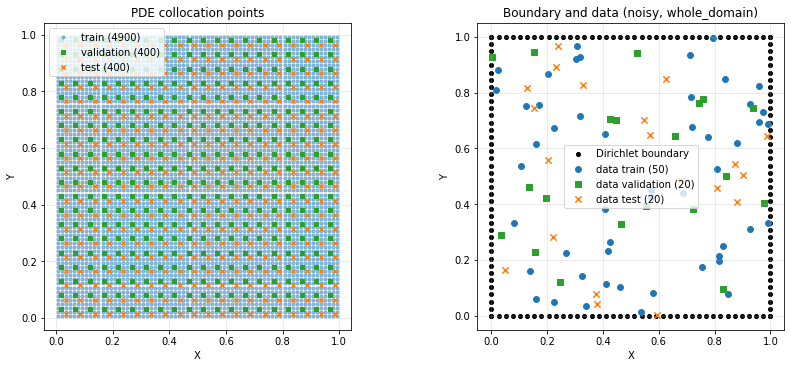

In [10]:
plot_data_split()


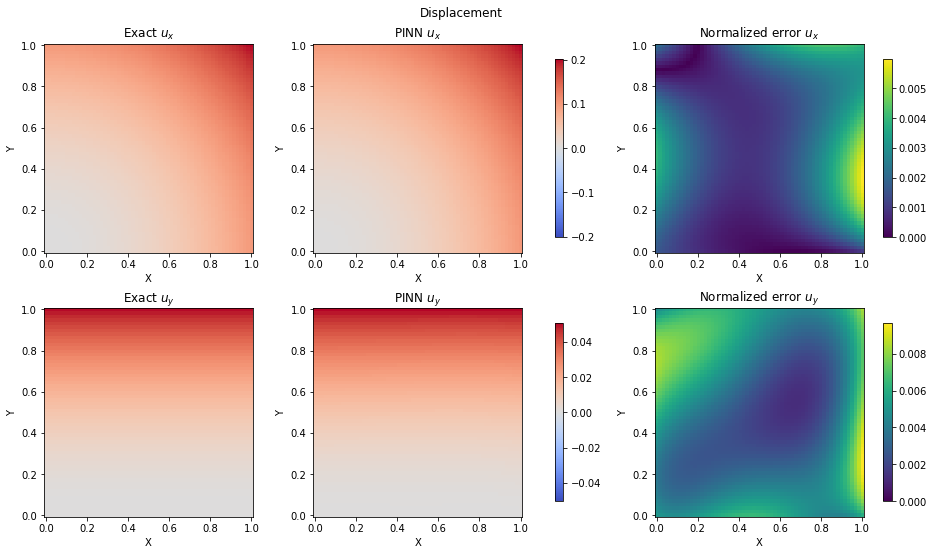

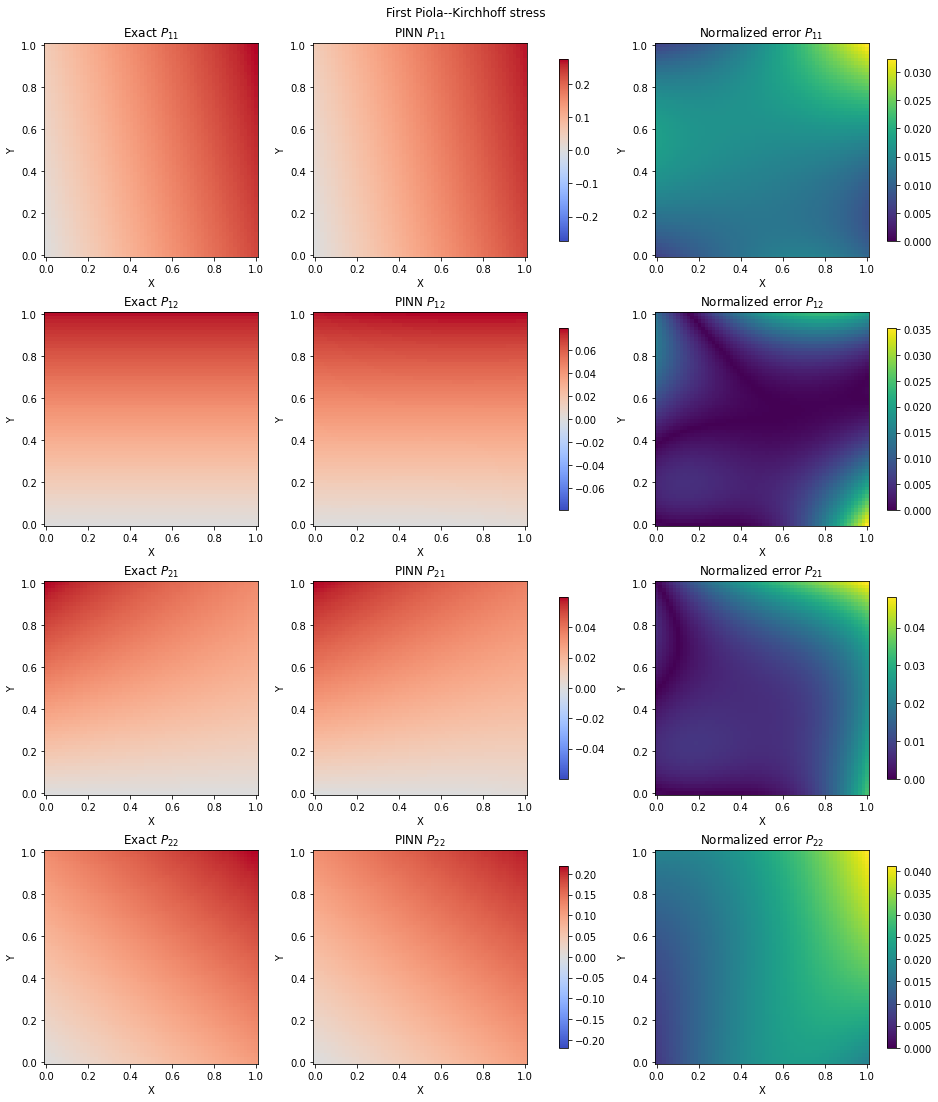

In [11]:
plot_solution()


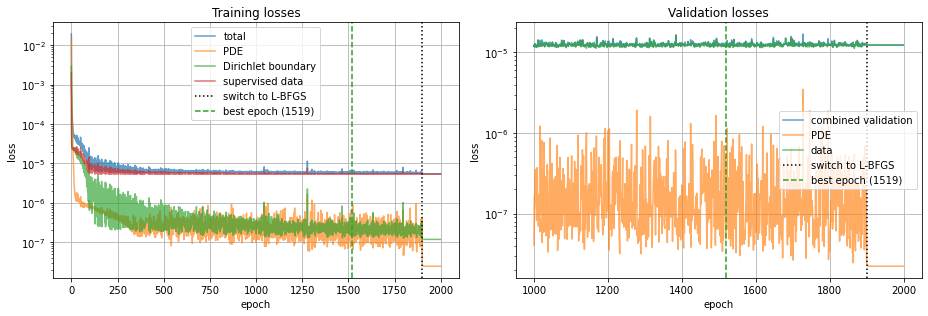

In [12]:
plot_losses()


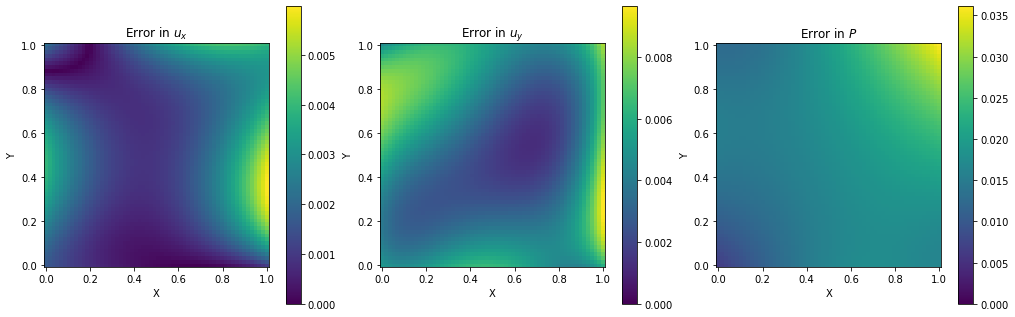

In [13]:
plot_errors()


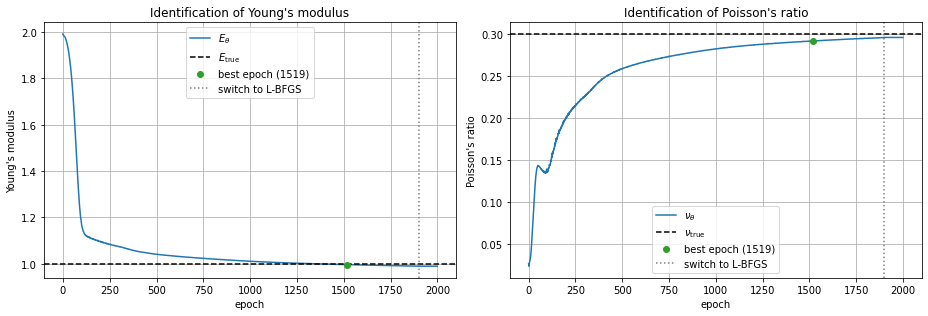

In [14]:
plot_material_parameters()
